# Analysis of Control nodes (In progress)

#### Done

1. From node communities data, find out the  time spent in sync cluster for each node
2. From connectivity data, find the out degree
3. Calculate median time spent for 200 iterations (as of now)

#### In progress

1. Consider those nodes which have
    
    A. High out degree but low median time
    
    B. Low out degree but high median time

Find the nodes as stated in 3 and then remove them

In [1]:
import networkx as nx
import numpy as np
import pandas as pd 
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import matplotlib.pyplot as plt

from tes.DataUtils import DataUtils


#### Finding out degree using functionin DataUtils

In [27]:
l=DataUtils()
analyse = AnalysisFunc()
reader = DataRead()


../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [3]:
df_nc=reader.data_read_bz2('raw/FN/nc_200.bz2')

df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')


In [4]:
pm=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


In [28]:
# can get directly the out degree
l.OUT_DEGREE.shape

(426,)

In [6]:
l.WHOLE_BRAIN_CONN.shape
# here G is the directed graph
G = nx.from_numpy_array(l.WHOLE_BRAIN_CONN, create_using=nx.DiGraph())
out_degree_dict = dict(G.out_degree())

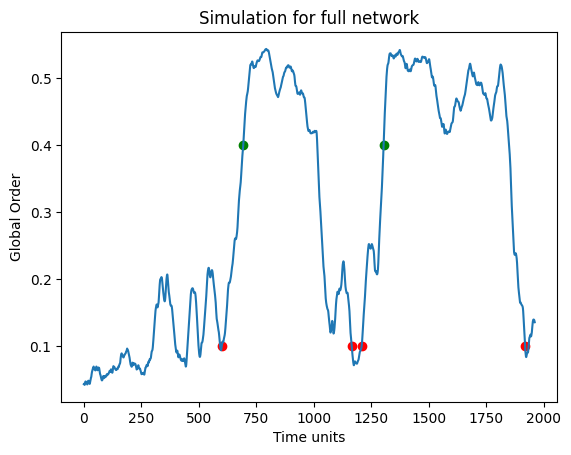

In [7]:
analyse.plot_global_synchrony(df_itr[77],0.05)

#### Compute time spent in main cluster

In [18]:
ts=analyse.compute_time_spent_mc(df_nc.loc[3])
type(ts)
dum=ts

#### Calculating MEDIAN time spent for whole node communities data

STEPS:
1. Take a 5000 x 426 dataframe
2. Calculate time spennt in MC for each node using compute_time_spent_mc function
3. Find such list of length 426 for each 5000 x 426 node community data
4. Store these list in dataframes of column 426
5. Then take median for every column to get the median time spent for any node


In [20]:
df_r=df_nc.reset_index(drop=True)

In [21]:
i=0
f=5000
time_list=[]
node_list=[]
while f < df_r.shape[0]:
    l=analyse.compute_time_spent_mc(df_r.iloc[i:f,:])
    node_list.append(l)
    i=f
    f+=5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape




(127, 426)

In [44]:
# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys=list(range(0,426))
mts_dict=dict(zip(keys,med_time_spent))
dict(sorted(mts_dict.items(), key=lambda item: item[1]))

{164: 0.0,
 169: 0.0,
 176: 0.0,
 177: 0.0,
 178: 0.0,
 179: 0.0,
 180: 0.0,
 181: 0.0,
 184: 0.0,
 187: 0.0,
 192: 0.0,
 193: 0.0,
 194: 0.0,
 195: 0.0,
 196: 0.0,
 197: 0.0,
 198: 0.0,
 203: 0.0,
 204: 0.0,
 209: 0.0,
 210: 0.0,
 211: 0.0,
 377: 0.0,
 382: 0.0,
 389: 0.0,
 390: 0.0,
 391: 0.0,
 392: 0.0,
 393: 0.0,
 394: 0.0,
 397: 0.0,
 400: 0.0,
 405: 0.0,
 406: 0.0,
 407: 0.0,
 408: 0.0,
 409: 0.0,
 410: 0.0,
 411: 0.0,
 416: 0.0,
 417: 0.0,
 422: 0.0,
 423: 0.0,
 424: 0.0,
 414: 2.0,
 206: 7.0,
 201: 9.0,
 419: 9.0,
 399: 25.0,
 415: 29.0,
 186: 31.0,
 199: 36.0,
 202: 37.0,
 420: 38.0,
 412: 41.0,
 418: 46.0,
 182: 47.0,
 401: 49.0,
 404: 49.0,
 188: 50.0,
 395: 50.0,
 191: 52.0,
 205: 52.0,
 207: 56.0,
 403: 76.0,
 190: 77.0,
 183: 93.0,
 384: 98.0,
 171: 101.0,
 402: 106.0,
 396: 109.0,
 189: 120.0,
 378: 128.0,
 212: 141.0,
 165: 148.0,
 398: 164.0,
 425: 166.0,
 208: 176.0,
 421: 195.0,
 167: 206.0,
 380: 208.0,
 362: 211.0,
 172: 215.0,
 185: 219.0,
 385: 242.0,
 149: 257.0

In [45]:
out_degree=list(l.OUT_DEGREE)
out_deg_dict=dict(zip(keys,out_degree))
dict(sorted(out_deg_dict.items(), key=lambda item: item[1]))

{57: 0,
 71: 0,
 73: 0,
 74: 0,
 98: 0,
 114: 0,
 117: 0,
 166: 0,
 195: 0,
 270: 0,
 284: 0,
 286: 0,
 287: 0,
 311: 0,
 327: 0,
 330: 0,
 379: 0,
 408: 0,
 105: 1,
 170: 1,
 203: 1,
 207: 1,
 318: 1,
 383: 1,
 416: 1,
 420: 1,
 38: 2,
 90: 2,
 92: 2,
 102: 2,
 116: 2,
 135: 2,
 172: 2,
 189: 2,
 205: 2,
 209: 2,
 251: 2,
 303: 2,
 305: 2,
 315: 2,
 329: 2,
 348: 2,
 385: 2,
 402: 2,
 418: 2,
 422: 2,
 32: 3,
 55: 3,
 61: 3,
 89: 3,
 97: 3,
 202: 3,
 206: 3,
 245: 3,
 268: 3,
 274: 3,
 302: 3,
 310: 3,
 415: 3,
 419: 3,
 39: 4,
 42: 4,
 44: 4,
 69: 4,
 91: 4,
 106: 4,
 132: 4,
 155: 4,
 252: 4,
 255: 4,
 257: 4,
 282: 4,
 304: 4,
 319: 4,
 345: 4,
 368: 4,
 99: 5,
 100: 5,
 108: 5,
 115: 5,
 125: 5,
 129: 5,
 133: 5,
 134: 5,
 201: 5,
 312: 5,
 313: 5,
 321: 5,
 328: 5,
 338: 5,
 342: 5,
 346: 5,
 347: 5,
 414: 5,
 11: 6,
 31: 6,
 49: 6,
 67: 6,
 77: 6,
 87: 6,
 192: 6,
 208: 6,
 224: 6,
 244: 6,
 262: 6,
 280: 6,
 290: 6,
 300: 6,
 405: 6,
 421: 6,
 13: 7,
 20: 7,
 79: 7,
 81: 7,
 94

In [39]:
med_time_spent.sort()
med_time_spent

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 2.0,
 7.0,
 9.0,
 9.0,
 25.0,
 29.0,
 31.0,
 36.0,
 37.0,
 38.0,
 41.0,
 46.0,
 47.0,
 49.0,
 49.0,
 50.0,
 50.0,
 52.0,
 52.0,
 56.0,
 76.0,
 77.0,
 93.0,
 98.0,
 101.0,
 106.0,
 109.0,
 120.0,
 128.0,
 141.0,
 148.0,
 164.0,
 166.0,
 176.0,
 195.0,
 206.0,
 208.0,
 211.0,
 215.0,
 219.0,
 242.0,
 257.0,
 269.0,
 280.0,
 292.0,
 293.0,
 294.0,
 313.0,
 317.0,
 327.0,
 332.0,
 333.0,
 333.0,
 335.0,
 339.0,
 350.0,
 357.0,
 377.0,
 388.0,
 436.0,
 448.0,
 494.0,
 510.0,
 534.0,
 535.0,
 571.0,
 635.0,
 656.0,
 663.0,
 664.0,
 680.0,
 685.0,
 732.0,
 745.0,
 798.0,
 837.0,
 909.0,
 927.0,
 951.0,
 960.0,
 961.0,
 964.0,
 976.0,
 980.0,
 992.0,
 994.0,
 997.0,
 1001.0,
 1001.0,
 1002.0,
 1004.0,
 1006.0,
 1025.0,
 1027.0,
 1030

#### Finding median time spent of each node in sync cluster and then find median over 200 iterations